In [1]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.models.baseline_models import (
    naive_forecast,
    moving_average_forecast,
    seasonal_naive_forecast,
    evaluate_baselines
)
from src.models.classical_models import (
    holt_winters_forecast,
    arima_forecast,
    sarima_forecast,
    prophet_forecast
)
from src.models.walk_forward import walk_forward_split, evaluate_model_cv
from src.evaluation.metrics import evaluate_all, metrics_dataframe

print("All imports done!")

All imports done!


In [2]:
df = pd.read_parquet("data/processed/train_features.parquet")

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Stores:", df["Store"].nunique())
print("Departments:", df["Dept"].nunique())

Shape: (408436, 46)
Date range: 2010-03-05 00:00:00 to 2012-10-26 00:00:00
Stores: 45
Departments: 81


Store 1, Dept 1
Total weeks: 139
Date range: 2010-03-05 to 2012-10-26


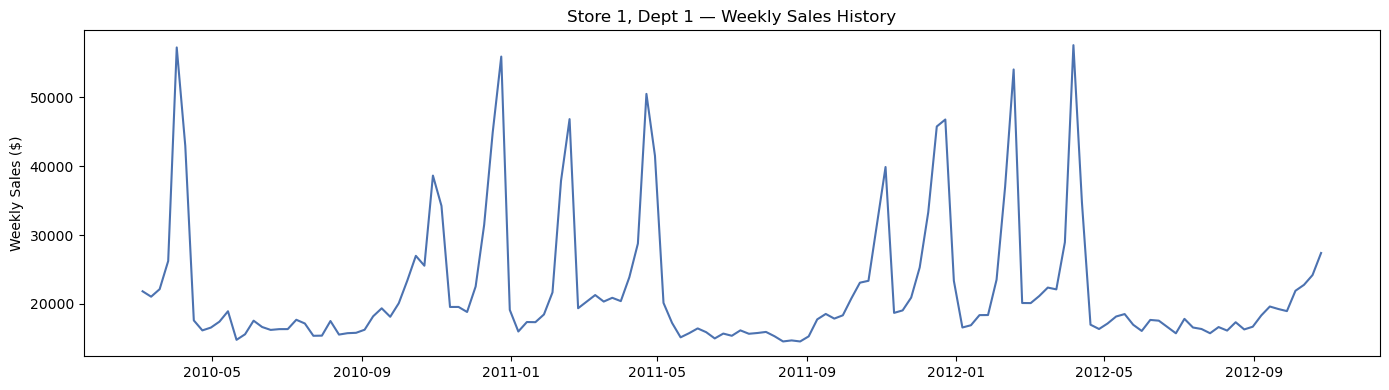

In [3]:
# Pick Store 1, Department 1 for our example
STORE = 1
DEPT  = 1

# Filter to just this store-department
series_df = df[
    (df["Store"] == STORE) &
    (df["Dept"] == DEPT)
].sort_values("Date").reset_index(drop=True)

print(f"Store {STORE}, Dept {DEPT}")
print(f"Total weeks: {len(series_df)}")
print(f"Date range: {series_df['Date'].min().date()} to {series_df['Date'].max().date()}")

# Plot it first so we know what we're working with
plt.figure(figsize=(14, 4))
plt.plot(series_df["Date"], series_df["Weekly_Sales"], color="#4C72B0", linewidth=1.5)
plt.title(f"Store {STORE}, Dept {DEPT} — Weekly Sales History")
plt.ylabel("Weekly Sales ($)")
plt.tight_layout()
plt.show()

In [4]:
# Use last 12 weeks as test set
TEST_WEEKS = 12

train_df = series_df.iloc[:-TEST_WEEKS].copy()
test_df  = series_df.iloc[-TEST_WEEKS:].copy()

print(f"Training weeks : {len(train_df)}")
print(f"Test weeks     : {len(test_df)}")
print(f"Train ends on  : {train_df['Date'].max().date()}")
print(f"Test starts on : {test_df['Date'].min().date()}")

Training weeks : 127
Test weeks     : 12
Train ends on  : 2012-08-03
Test starts on : 2012-08-10


In [5]:

print("BASELINE MODELS")


actual = test_df["Weekly_Sales"].values

# Model 1: Naive
naive_preds = naive_forecast(train_df, horizon=TEST_WEEKS)
naive_metrics = evaluate_all(actual, naive_preds)
print(f"Naive          | RMSE: {naive_metrics['RMSE']:8.2f} | MAPE: {naive_metrics['MAPE']:.2f}%")

# Model 2: Moving Average
ma_preds = moving_average_forecast(train_df, horizon=TEST_WEEKS, window=4)
ma_metrics = evaluate_all(actual, ma_preds)
print(f"Moving Average | RMSE: {ma_metrics['RMSE']:8.2f} | MAPE: {ma_metrics['MAPE']:.2f}%")

# Model 3: Seasonal Naive
sn_preds = seasonal_naive_forecast(train_df, horizon=TEST_WEEKS)
sn_metrics = evaluate_all(actual, sn_preds)
print(f"Seasonal Naive | RMSE: {sn_metrics['RMSE']:8.2f} | MAPE: {sn_metrics['MAPE']:.2f}%")

BASELINE MODELS
Naive          | RMSE:  4684.67 | MAPE: 15.13%
Moving Average | RMSE:  4906.10 | MAPE: 16.09%
Seasonal Naive | RMSE:  1776.66 | MAPE: 7.37%


In [6]:

print("HOLT-WINTERS MODEL")


# Holt-Winters needs a Series with DatetimeIndex
train_series = train_df.set_index("Date")["Weekly_Sales"]

hw_preds   = holt_winters_forecast(train_series, horizon=TEST_WEEKS)
hw_metrics = evaluate_all(actual, hw_preds)
print(f"Holt-Winters   | RMSE: {hw_metrics['RMSE']:8.2f} | MAPE: {hw_metrics['MAPE']:.2f}%")

HOLT-WINTERS MODEL
  Fitting Holt-Winters model...


C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


  Done. First 3 predictions: [14247.0, 14418.0, 14322.0]
Holt-Winters   | RMSE:  2704.11 | MAPE: 9.52%


In [7]:

print("ARIMA MODEL")


# (p=1, d=1, q=1) — good starting point
# d=1 because our stationarity test in Phase 2 suggested differencing
arima_preds   = arima_forecast(train_series, horizon=TEST_WEEKS, order=(1, 1, 1))
arima_metrics = evaluate_all(actual, arima_preds)
print(f"ARIMA(1,1,1)   | RMSE: {arima_metrics['RMSE']:8.2f} | MAPE: {arima_metrics['MAPE']:.2f}%")

ARIMA MODEL
  Fitting ARIMA(1, 1, 1) model...
  Done. First 3 predictions: [18878.0, 20180.0, 20933.0]
ARIMA(1,1,1)   | RMSE:  3233.10 | MAPE: 15.08%


C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [8]:

print("SARIMA MODEL")


# S=52 means seasonal period = 52 weeks (1 year)
sarima_preds   = sarima_forecast(
    train_series,
    horizon=TEST_WEEKS,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52)
)
sarima_metrics = evaluate_all(actual, sarima_preds)
print(f"SARIMA         | RMSE: {sarima_metrics['RMSE']:8.2f} | MAPE: {sarima_metrics['MAPE']:.2f}%")

SARIMA MODEL
  Fitting SARIMA(1, 1, 1)x(1, 1, 1, 52) model...
  (This may take 1-2 minutes for weekly data...)


C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


  Done. First 3 predictions: [16594.0, 16802.0, 16996.0]
SARIMA         | RMSE:  1764.32 | MAPE: 6.28%


In [9]:

print("PROPHET MODEL")


prophet_preds   = prophet_forecast(train_df, horizon=TEST_WEEKS)
prophet_metrics = evaluate_all(actual, prophet_preds)
print(f"Prophet        | RMSE: {prophet_metrics['RMSE']:8.2f} | MAPE: {prophet_metrics['MAPE']:.2f}%")

PROPHET MODEL
  Fitting Prophet model...


10:33:19 - cmdstanpy - INFO - Chain [1] start processing
10:33:20 - cmdstanpy - INFO - Chain [1] done processing


  Done. First 3 predictions: [14909.0, 15118.0, 15551.0]
Prophet        | RMSE:  1943.37 | MAPE: 8.82%


In [10]:
print("=" * 50)
print("ALL MODELS COMPARISON")
print("=" * 50)

all_results = {
    "Naive":           naive_metrics,
    "Moving Average":  ma_metrics,
    "Seasonal Naive":  sn_metrics,
    "Holt-Winters":    hw_metrics,
    "ARIMA(1,1,1)":    arima_metrics,
    "SARIMA":          sarima_metrics,
    "Prophet":         prophet_metrics,
}

results_table = metrics_dataframe(all_results)
print(results_table.to_string())
print("\nBest model (lowest RMSE):", results_table.index[0])

ALL MODELS COMPARISON
                      MAE       RMSE     MAPE    SMAPE      R2
Model                                                         
SARIMA          1370.2128  1764.3150   6.2834   6.5494  0.7231
Seasonal Naive  1456.2783  1776.6567   7.3723   7.5696  0.7192
Prophet         1742.8712  1943.3707   8.8246   9.3067  0.6641
Holt-Winters    1942.7378  2704.1125   9.5195   9.5909  0.3496
ARIMA(1,1,1)    2870.9170  3233.1029  15.0846  14.1705  0.0702
Naive           3413.3833  4684.6717  15.1285  17.3285 -0.9521
Moving Average  3619.9683  4906.0988  16.0889  18.5566 -1.1410

Best model (lowest RMSE): SARIMA


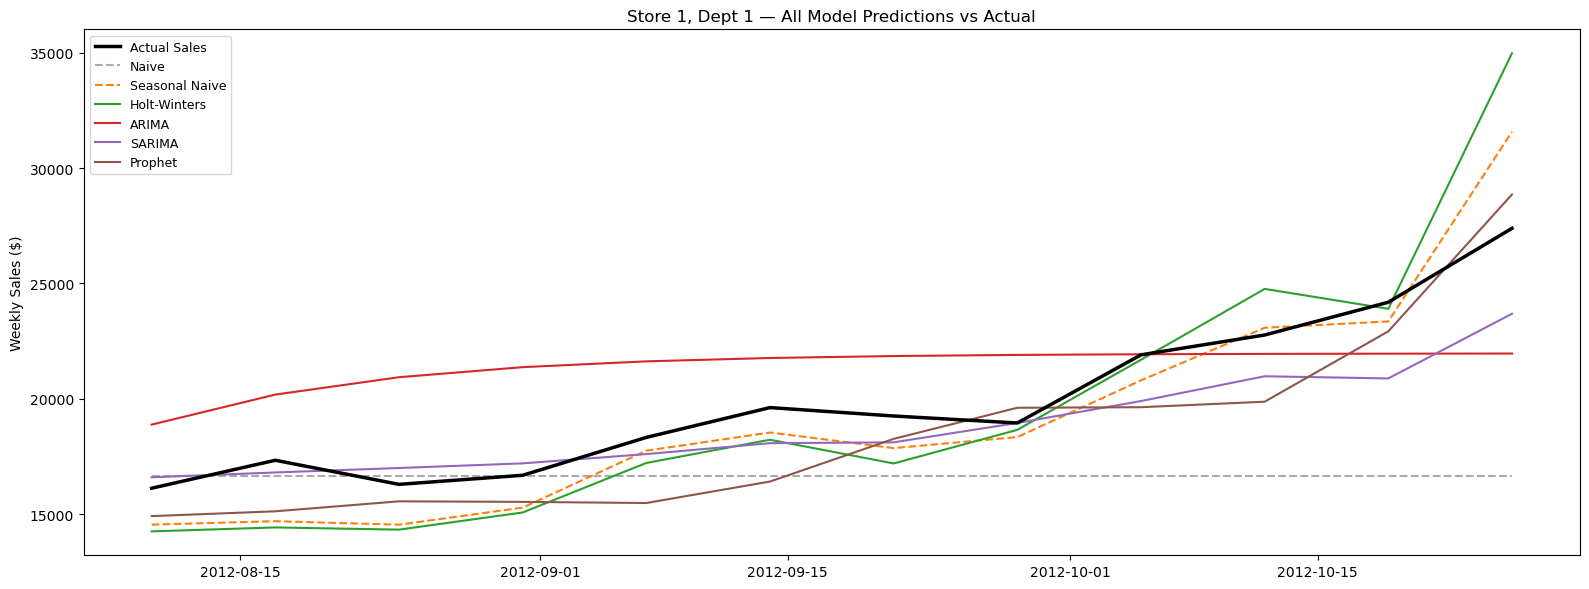

In [11]:
fig, ax = plt.subplots(figsize=(16, 6))

# Plot actual values
ax.plot(test_df["Date"], actual,
        label="Actual Sales", color="black", linewidth=2.5, zorder=5)

# Plot each model's predictions
predictions_to_plot = {
    "Naive":          (naive_preds,   "#AAAAAA", "--"),
    "Seasonal Naive": (sn_preds,      "#FF7F0E", "--"),
    "Holt-Winters":   (hw_preds,      "#2CA02C", "-"),
    "ARIMA":          (arima_preds,   "#D62728", "-"),
    "SARIMA":         (sarima_preds,  "#9467BD", "-"),
    "Prophet":        (prophet_preds, "#8C564B", "-"),
}

for model_name, (preds, color, style) in predictions_to_plot.items():
    ax.plot(test_df["Date"], preds,
            label=model_name, color=color, linestyle=style, linewidth=1.5)

ax.set_title(f"Store {STORE}, Dept {DEPT} — All Model Predictions vs Actual")
ax.set_ylabel("Weekly Sales ($)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("reports/figures/09_model_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print("=" * 50)
print("WALK-FORWARD CROSS VALIDATION")
print("=" * 50)

# Wrap Holt-Winters in a simple function for walk-forward
def hw_model(train_df, horizon):
    train_series = train_df.set_index("Date")["Weekly_Sales"]
    return holt_winters_forecast(train_series, horizon=horizon)

def arima_model(train_df, horizon):
    train_series = train_df.set_index("Date")["Weekly_Sales"]
    return arima_forecast(train_series, horizon=horizon, order=(1, 1, 1))

print("\n--- Holt-Winters ---")
hw_cv = evaluate_model_cv(hw_model, df, store=STORE, dept=DEPT, n_folds=3, test_weeks=12)

print("\n--- ARIMA ---")
arima_cv = evaluate_model_cv(arima_model, df, store=STORE, dept=DEPT, n_folds=3, test_weeks=12)

WALK-FORWARD CROSS VALIDATION

--- Holt-Winters ---

Walk-Forward CV — Store 1, Dept 1 (139 weeks total)
  Fold 1: Train 2010-03-05 → 2012-08-03 (127 weeks) | Test 2012-08-10 → 2012-10-26 (12 weeks)
  Fold 2: Train 2010-03-05 → 2012-05-11 (115 weeks) | Test 2012-05-18 → 2012-08-03 (12 weeks)
  Fold 3: Train 2010-03-05 → 2012-02-17 (103 weeks) | Test 2012-02-24 → 2012-05-11 (12 weeks)
  Fitting Holt-Winters model...


C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


  Done. First 3 predictions: [14247.0, 14418.0, 14322.0]
  Fold 1 — RMSE: 2704.11 | MAPE: 9.52% | MAE: 1942.74
  Fitting Holt-Winters model...


C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


  Done. First 3 predictions: [14307.0, 14941.0, 16121.0]
  Fold 2 — RMSE: 2041.68 | MAPE: 10.27% | MAE: 1770.15
  Fitting Holt-Winters model...
  Fold 3 failed: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.

  Average — RMSE: 2372.90 | MAPE: 9.90% | R2: -2.2758

--- ARIMA ---

Walk-Forward CV — Store 1, Dept 1 (139 weeks total)
  Fold 1: Train 2010-03-05 → 2012-08-03 (127 weeks) | Test 2012-08-10 → 2012-10-26 (12 weeks)
  Fold 2: Train 2010-03-05 → 2012-05-11 (115 weeks) | Test 2012-05-18 → 2012-08-03 (12 weeks)
  Fold 3: Train 2010-03-05 → 2012-02-17 (103 weeks) | Test 2012-02-24 → 2012-05-11 (12 weeks)
  Fitting ARIMA(1, 1, 1) model...


C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


  Done. First 3 predictions: [18878.0, 20180.0, 20933.0]
  Fold 1 — RMSE: 3233.10 | MAPE: 15.08% | MAE: 2870.92
  Fitting ARIMA(1, 1, 1) model...
  Done. First 3 predictions: [20160.0, 21290.0, 21930.0]
  Fold 2 — RMSE: 5594.15 | MAPE: 32.56% | MAE: 5411.92
  Fitting ARIMA(1, 1, 1) model...


C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\conda\Lib\site-packages\statsmod

  Done. First 3 predictions: [56158.0, 55119.0, 55634.0]
  Fold 3 — RMSE: 32821.88 | MAPE: 155.40% | MAE: 31212.00

  Average — RMSE: 13883.04 | MAPE: 67.68% | R2: -16.9589


In [13]:
import os
import json

os.makedirs("reports/metrics", exist_ok=True)

# Save all model scores
with open("reports/metrics/phase4_results.json", "w") as f:
    json.dump(all_results, f, indent=4)

print("Results saved to reports/metrics/phase4_results.json")
print("\n" + "=" * 50)
print("PHASE 4 COMPLETE!")
print("=" * 50)
print("\nWhat we built:")
print("  - 3 baseline models (Naive, Moving Average, Seasonal Naive)")
print("  - 4 classical models (Holt-Winters, ARIMA, SARIMA, Prophet)")
print("  - Walk-forward cross validation")
print("  - Full comparison table and plots")
print(f"\nBest model so far: {results_table.index[0]}")
print("\nNext: Phase 5 — ML models (LightGBM, XGBoost, CatBoost)")

Results saved to reports/metrics/phase4_results.json

PHASE 4 COMPLETE!

What we built:
  - 3 baseline models (Naive, Moving Average, Seasonal Naive)
  - 4 classical models (Holt-Winters, ARIMA, SARIMA, Prophet)
  - Walk-forward cross validation
  - Full comparison table and plots

Best model so far: SARIMA

Next: Phase 5 — ML models (LightGBM, XGBoost, CatBoost)
